# Example 6: Two-dimensional reactor hotspots and parameter fitting

This example extends the dynamic finite-volume model of Example 5 to an axisymmetric tubular reactor with axial convection and radial transport. The model is pseudo-homogeneous: one concentration and one temperature describe the reacting medium.

The example has two applications:

- resolving the axial-radial hotspot generated by exothermic reaction and wall cooling, and
- estimating a wall heat-transfer coefficient and a kinetic pre-exponential factor from reproducible synthetic measurements.

There is no axial dispersion. Both axial and radial coordinates are discretized, and the resulting ODE system is integrated with SciPy's BDF method.


In [41]:
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from scipy.sparse import lil_matrix

# Publication settings shared by Examples 4--6.  LaTeX typesets all text in
# Computer Modern.  PDF is the primary vector format; the 600-dpi PNG files
# are retained only as raster fallbacks for workflows that cannot read PDF.
plt.style.use("default")
plt.rcParams.update({
    "figure.figsize": (7.0, 4.2),
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.usetex": True,
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "grid.linewidth": 0.5,
    "lines.linewidth": 1.4,
    "axes.unicode_minus": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

FIGURE_DIR = Path("publication_figures")
FIGURE_DIR.mkdir(exist_ok=True)


def save_publication_figure(fig, stem):
    """Write an editable vector PDF and a 600-dpi raster fallback."""
    fig.savefig(FIGURE_DIR / f"{stem}.pdf", format="pdf", facecolor="white")
    fig.savefig(FIGURE_DIR / f"{stem}.png", format="png", dpi=600, facecolor="white")


## Governing equations

For axial coordinate $z$ and radial coordinate $r$, the balances are

$$\frac{\partial c_{\mathrm{EO}}}{\partial t}
=-u\frac{\partial c_{\mathrm{EO}}}{\partial z}
+D_{r}\frac{1}{r}\frac{\partial}{\partial r}
\left(r\frac{\partial c_{\mathrm{EO}}}{\partial r}\right)-r_{\mathrm{rxn}},$$

$$\rho c_p\frac{\partial T}{\partial t}
=-\rho c_pu\frac{\partial T}{\partial z}
+\lambda_r\frac{1}{r}\frac{\partial}{\partial r}
\left(r\frac{\partial T}{\partial r}\right)
-r_{\mathrm{rxn}}\Delta_RH,$$

with

$$r_{\mathrm{rxn}}=k_0\exp\left(-\frac{E_A}{RT}\right)c_{\mathrm{EO}}.$$

At the centerline, symmetry gives zero radial flux. The wall is impermeable to EO and exchanges heat with a coolant:

$$\left.\frac{\partial c_{\mathrm{EO}}}{\partial r}\right|_{r=0,R_R}=0,
\qquad
-\lambda_r\left.\frac{\partial T}{\partial r}\right|_{R_R}=h_w(T_w-T_C).$$

The radial finite volumes are annuli. Their exact cross-sectional areas and face circumferences are used, so the $1/r$ geometry is handled without a singular calculation at the centerline. A half-cell conduction resistance and the wall-film resistance are combined at the outer face.


In [42]:
class Parameters:
    def __init__(self, Nz=48, Nr=8, EA=72.5e3):
        # Geometry and discretization
        self.L = 300.0              # reactor length / m
        self.d_R = 0.03             # reactor diameter / m
        self.R_R = self.d_R / 2     # reactor radius / m
        self.u = 1.0                # fluid velocity / m s^-1
        self.Nz = Nz
        self.Nr = Nr
        self.dz = self.L / self.Nz
        self.dr = self.R_R / self.Nr
        self.z = (np.arange(self.Nz) + 0.5) * self.dz
        self.n_cells = self.Nz * self.Nr

        # Annular cross-sectional areas and radial face circumferences
        self.z_faces = np.linspace(0.0, self.L, self.Nz + 1)
        self.r = (np.arange(self.Nr) + 0.5) * self.dr
        self.r_faces = np.linspace(0.0, self.R_R, self.Nr + 1)
        self.area_annulus = np.pi * (self.r_faces[1:]**2 - self.r_faces[:-1]**2)
        self.radial_face_area = 2.0 * np.pi * self.r_faces  # per unit axial length

        # Flow, physical properties and heat transfer (Example 2)
        self.u = 1.0                # fluid velocity / m s^-1
        self.rho = 1000.0           # kg m^-3
        self.cp = 4190.0            # J kg^-1 K^-1
        self.h_w = 500.0            # W m^-2 K^-1
        self.a_w = 4.0 / self.d_R   # wall area per reactor volume / m^-1
        self.D_r = 1.0e-7            # radial mass dispersion / m^2 s^-1
        self.lambda_r = 4.5          # effective radial thermal conductivity / W m^-1 K^-1
        self.R = 8.314               # J mol^-1 K^-1

        # Inlet and coolant
        self.c_in = 2.27e3           # mol m^-3
        self.T_in = 423.0            # K
        self.T_C = 440.0             # K

        # Reaction parameters
        self.EA = EA             # J mol^-1
        self.k0_reference = 5.01e6  # s^-1
        self.EA_reference = 72.5e3  # J mol^-1
        self.delta_H = -92.2e3       # J mol^-1

        self.T_kinetic_reference = 440.0
        k_at_reference = self.k0_reference * np.exp(
            -self.EA_reference / (self.R * self.T_kinetic_reference)
        )
        self.k0 = k_at_reference / np.exp(
            -self.EA / (self.R * self.T_kinetic_reference)
        )

        self.t_end = 450.0           # s


In [43]:
def radial_transport(field, coefficient, p, coolant_temperature=None, h_wall=None):
    # Finite-volume radial divergence for an array shaped (Nz, Nr).
    result = np.zeros_like(field)

    # Interior radial faces. Positive flux is directed toward larger radius.
    face_flux = (
        coefficient
        * p.radial_face_area[1:-1][None, :]
        * (field[:, 1:] - field[:, :-1])
        / p.dr
    )
    result[:, :-1] += face_flux / p.area_annulus[:-1]
    result[:, 1:] -= face_flux / p.area_annulus[1:]

    # At r = 0, the face area is zero. At the outer wall, mass flux is zero.
    if coolant_temperature is not None:
        overall_h = 1.0 / (p.dr / (2.0 * coefficient) + 1.0 / h_wall)
        wall_loss = (
            overall_h
            * p.radial_face_area[-1]
            * (field[:, -1] - coolant_temperature)
            / p.area_annulus[-1]
        )
        result[:, -1] -= wall_loss

    return result


def reactor_2d(t, y, p, h_wall, k0):
    n = p.n_cells
    c = y[:n].reshape(p.Nz, p.Nr)
    T = y[n:].reshape(p.Nz, p.Nr)

    # First-order upwind fluxes in the axial direction
    c_upwind = np.vstack([np.full((1, p.Nr), p.c_in), c[:-1, :]])
    T_upwind = np.vstack([np.full((1, p.Nr), p.T_in), T[:-1, :]])

    k = k0 * np.exp(-p.EA / (p.R * T))
    rate = k * c

    dc_dt = (
        -p.u * (c - c_upwind) / p.dz
        + radial_transport(c, p.D_r, p)
        - rate
    )
    dT_dt = (
        -p.u * (T - T_upwind) / p.dz
        + radial_transport(T, p.lambda_r, p, p.T_C, h_wall) / (p.rho * p.cp)
        + (-p.delta_H) * rate / (p.rho * p.cp)
    )
    return np.r_[dc_dt.ravel(), dT_dt.ravel()]


def jacobian_sparsity_2d(p):
    # Local axial/radial dependencies of the two-field ODE system.
    n = p.n_cells
    S = lil_matrix((2*n, 2*n), dtype=int)
    for iz in range(p.Nz):
        for ir in range(p.Nr):
            q = iz*p.Nr + ir
            neighbors = [q]
            if iz > 0:
                neighbors.append(q - p.Nr)
            if ir > 0:
                neighbors.append(q - 1)
            if ir < p.Nr - 1:
                neighbors.append(q + 1)

            S[q, neighbors] = 1
            S[q, n + q] = 1
            S[n + q, q] = 1
            S[n + q, [n + j for j in neighbors]] = 1
    return S.tocsr()


def simulate_2d(p, h_wall=None, k0=None, t_eval=None):
    if h_wall is None:
        h_wall = p.h_w
    if k0 is None:
        k0 = p.k0

    y0 = np.r_[
        np.full(p.n_cells, p.c_in),
        np.full(p.n_cells, p.T_in),
    ]
    started = time.perf_counter()
    solution = solve_ivp(
        reactor_2d,
        (0.0, p.t_end),
        y0,
        args=(p, h_wall, k0),
        method="BDF",
        t_eval=t_eval,
        rtol=3e-6,
        atol=np.r_[
            np.full(p.n_cells, 2e-6),
            np.full(p.n_cells, 2e-6),
        ],
        jac_sparsity=jacobian_sparsity_2d(p),
    )
    solution.runtime = time.perf_counter() - started
    if not solution.success:
        raise RuntimeError(solution.message)
    return solution


def unpack_solution(solution, p, column=-1):
    c = solution.y[:p.n_cells, column].reshape(p.Nz, p.Nr)
    T = solution.y[p.n_cells:, column].reshape(p.Nz, p.Nr)
    return c, T


## 1 Dynamic hotspot simulation

The reactor initially contains unreacted feed at the inlet temperature. Wall heating/cooling and reaction then establish a two-dimensional profile. The selected grid contains 48 axial by 8 radial finite volumes, or 768 dynamic states for concentration and temperature together.


In [44]:
p = Parameters(Nz=300, Nr=8, EA=150.0e3)
times = np.linspace(0,p.t_end,num=int(p.t_end+1),endpoint=True)
solution = simulate_2d(p, t_eval=times)
c_final, T_final = unpack_solution(solution, p)

hot_index = np.unravel_index(np.argmax(T_final), T_final.shape)
iz_hot, ir_hot = hot_index
center_wall_difference = T_final[iz_hot, 0] - T_final[iz_hot, -1]

print(f"ODE states: {2*p.n_cells}")
print(f"BDF runtime: {solution.runtime:.3f} s; function evaluations: {solution.nfev}")
print(
    f"Hotspot: T = {T_final[hot_index]:.2f} K at "
    f"z = {p.z[iz_hot]:.1f} m, r = {1000*p.r[ir_hot]:.2f} mm"
)
print(f"Center-to-wall difference at hotspot plane: {center_wall_difference:.2f} K")


ODE states: 4800
BDF runtime: 0.936 s; function evaluations: 566
Hotspot: T = 473.42 K at z = 90.5 m, r = 0.94 mm
Center-to-wall difference at hotspot plane: 12.52 K


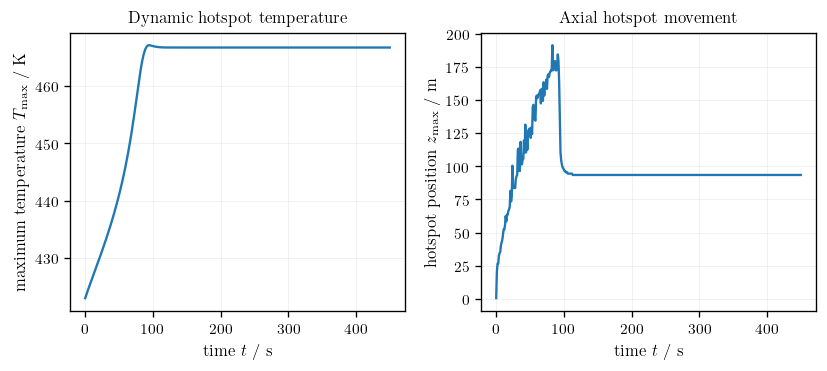

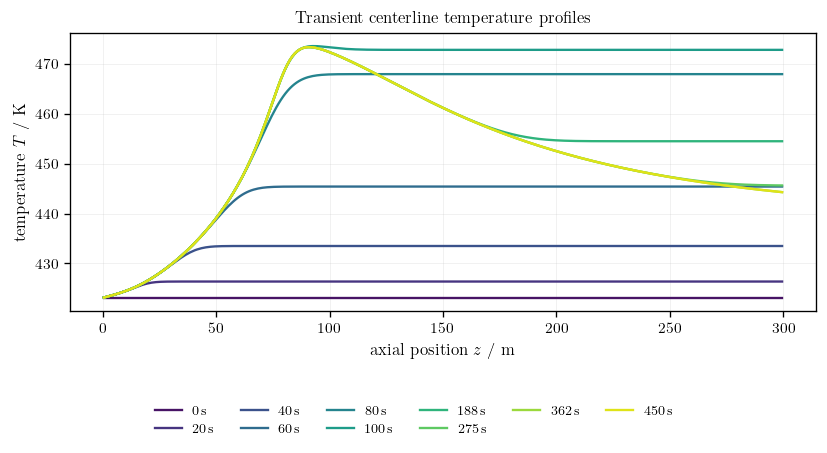

In [45]:
Tmax_time = []
Tavg_radial_time = []
zhot_time = []
for j in range(len(times)):
    _, Tj = unpack_solution(solution, p, j)
    Tavg_radial = np.average(Tj, axis=1, weights=p.area_annulus)
    idx = np.argmax(Tavg_radial)
    Tmax_time.append(Tavg_radial[idx])
    zhot_time.append(p.z[idx])

fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.2))
axes[0].plot(times, Tmax_time)
axes[0].set_xlabel(r"time $t$ / s")
axes[0].set_ylabel(r"maximum temperature $T_{\max}$ / K")
axes[0].set_title("Dynamic hotspot temperature")
axes[1].plot(times, zhot_time)
axes[1].set_xlabel(r"time $t$ / s")
axes[1].set_ylabel(r"hotspot position $z_{\max}$ / m")
axes[1].set_title("Axial hotspot movement")
fig.tight_layout()
save_publication_figure(fig, "ex6_hotspot_metrics")
plt.show()

fig, ax = plt.subplots(figsize=(7.0, 3.8))
profile_times = np.concatenate((np.linspace(0,100,5,False), np.linspace(100,p.t_end,5,True)))
colors = plt.cm.viridis(np.linspace(0.05, 0.95, len(profile_times)))

for t, color in zip(profile_times, colors):
    column = int(np.argmin(np.abs(times - t)))
    _, Tj = unpack_solution(solution, p, column)
    ax.plot(p.z, Tj[:, 0], color=color, label=fr"${t:.0f}\,\mathrm{{s}}$")

ax.set_xlabel(r"axial position $z$ / m")
ax.set_ylabel(r"temperature $T$ / K")
ax.set_title("Transient centerline temperature profiles")
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.005), ncol=6, frameon=False)
fig.tight_layout(rect=(0.0, 0.16, 1.0, 1.0))
save_publication_figure(fig, "ex6_transient_centerline")
plt.show()


## 2 Two dimensional Temperature profile

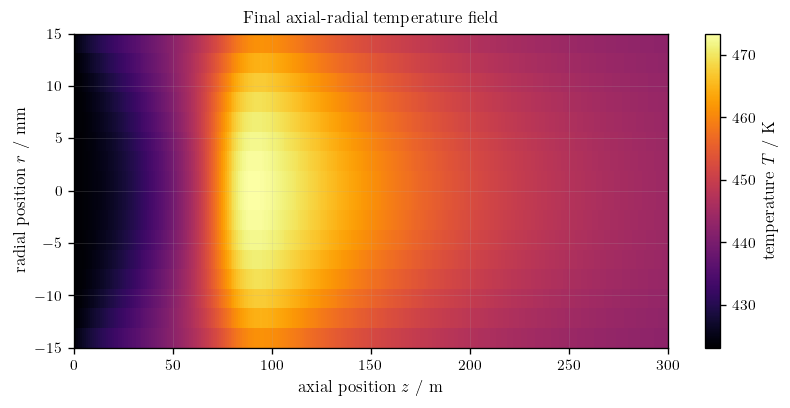

In [46]:
fig, ax = plt.subplots(figsize=(7.0, 3.5))
r_faces_mirrored = 1000*np.concatenate((-p.r_faces[:0:-1], p.r_faces))
T_final_mirrored = np.vstack((T_final.T[::-1], T_final.T))
mesh = ax.pcolormesh(
    p.z_faces,
    r_faces_mirrored,
    T_final_mirrored,
    shading="auto",
    cmap="inferno",
)
# ax.plot(p.z[iz_hot], 1000*p.r[ir_hot], "wo", ms=5, label="hotspot")
ax.set_xlabel(r"axial position $z$ / m")
ax.set_ylabel(r"radial position $r$ / mm")
ax.set_title("Final axial-radial temperature field")
fig.colorbar(mesh, ax=ax, label=r"temperature $T$ / K")
plt.tight_layout()
save_publication_figure(fig, "ex6_temperature_field")
plt.show()


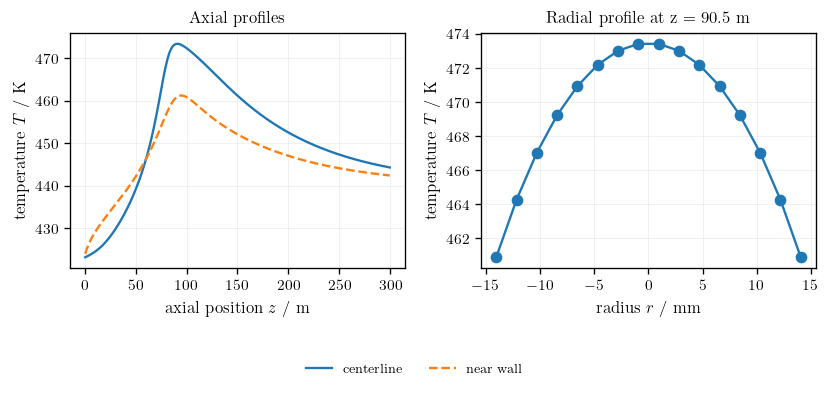

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.3))
axes[0].plot(p.z, T_final[:, 0], label="centerline")
axes[0].plot(p.z, T_final[:, -1], "--", label="near wall")
axes[0].set_xlabel(r"axial position $z$ / m")
axes[0].set_ylabel(r"temperature $T$ / K")
axes[0].set_title("Axial profiles")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.005), ncol=2, frameon=False)

axes[1].plot(1000*np.concatenate((np.flip(-p.r), p.r)), T_final_mirrored[:, iz_hot], "o-")
axes[1].set_xlabel(r"radius $r$ / mm")
axes[1].set_ylabel(r"temperature $T$ / K")
axes[1].set_title(f"Radial profile at z = {p.z[iz_hot]:.1f} m")
plt.tight_layout(rect=(0.0, 0.14, 1.0, 1.0))
save_publication_figure(fig, "ex6_axial_radial_profiles")
plt.show()


## 3 Parameter fitting $h_w$ and $k_0$

Simulated concentration and temperature measurements are sampled at six axial planes and three radial positions after 450 s. A fixed random seed makes the data reproducible. Independent Gaussian noise with standard deviations of 10 mol m$^{-3}$ and 0.25 K is added.

Both concentration and temperature are fitted because heat transfer and kinetics can have correlated effects on temperature alone. The two unknowns are constrained to remain positive by optimizing their logarithms:

$$\mathbf{x}=\left[\ln h_w,\;\ln k_0\right]^\mathsf{T}.$$

The parameters are obtained from the weighted, bounded nonlinear least-squares problem

$$
\widehat{\mathbf{x}}
=\underset{\mathbf{x}}{\operatorname{\,min}}\;
\frac{1}{2}\sum_{m\in\mathcal{M}}
\left[
\left(\frac{c_{\mathrm{EO},m}^{\mathrm{model}}(\mathbf{x})-
c_{\mathrm{EO},m}^{\mathrm{meas}}}{\sigma_c}\right)^2
+
\left(\frac{T_m^{\mathrm{model}}(\mathbf{x})-
T_m^{\mathrm{meas}}}{\sigma_T}\right)^2
\right],
$$

subject to the semi-discrete reactor model

$$
\frac{d\mathbf{y}}{dt}
=\mathbf{f}\!\left(\mathbf{y},\exp(x_1),\exp(x_2)\right),
\qquad \mathbf{y}(0)=\mathbf{y}_0,
$$

and the parameter bounds

$$
100\leq h_w\leq1000\ \mathrm{W\,m^{-2}\,K^{-1}},
\qquad
1.5\times10^6\leq k_0\leq1.2\times10^7\ \mathrm{s^{-1}}.
$$

Here, $\mathcal{M}$ contains all selected axial-radial measurement locations. Division by the assumed measurement standard deviations, $\sigma_c$ and $\sigma_T$, gives concentration and temperature residuals comparable statistical weight.



Synthetic data points: 18 concentration + 18 temperature
Random seed: 7; sigma_c = 50.0 mol m^-3; sigma_T = 1.00 K


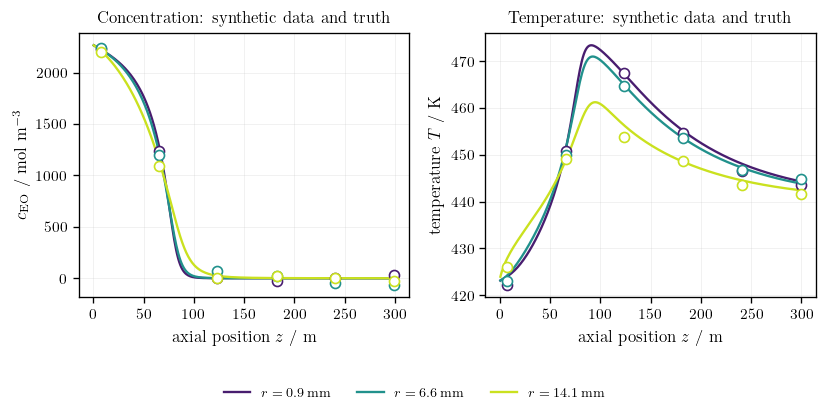

In [59]:
rng = np.random.default_rng(7)
iz_measure = np.linspace(7, p.Nz - 1, 6, dtype=int)
ir_measure = np.array([0, p.Nr//2 - 1, p.Nr - 1])
measurement_index = np.ix_(iz_measure, ir_measure)

sigma_c = 50   # mol m^-3
sigma_T = 1   # K
c_measured = c_final[measurement_index] + rng.normal(
    0.0, sigma_c, (len(iz_measure), len(ir_measure))
)
T_measured = T_final[measurement_index] + rng.normal(
    0.0, sigma_T, (len(iz_measure), len(ir_measure))
)

print(f"Synthetic data points: {c_measured.size} concentration + {T_measured.size} temperature")
print(f"Random seed: 7; sigma_c = {sigma_c:.1f} mol m^-3; sigma_T = {sigma_T:.2f} K")

z_measure = p.z[iz_measure]
measurement_colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(ir_measure)))
fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.5))
for j, (ir, color) in enumerate(zip(ir_measure, measurement_colors)):
    radial_label = fr"$r={1000*p.r[ir]:.1f}\,\mathrm{{mm}}$"
    axes[0].plot(p.z, c_final[:, ir], color=color, label=radial_label)
    axes[0].scatter(z_measure, c_measured[:, j], facecolors="white", edgecolors=color, zorder=3)
    axes[1].plot(p.z, T_final[:, ir], color=color)
    axes[1].scatter(z_measure, T_measured[:, j], facecolors="white", edgecolors=color, zorder=3)
axes[0].set_xlabel(r"axial position $z$ / m")
axes[0].set_ylabel(r"$c_{\mathrm{EO}}$ / mol m$^{-3}$")
axes[0].set_title("Concentration: synthetic data and truth")
axes[1].set_xlabel(r"axial position $z$ / m")
axes[1].set_ylabel(r"temperature $T$ / K")
axes[1].set_title("Temperature: synthetic data and truth")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.005), ncol=3, frameon=False)
fig.tight_layout(rect=(0.0, 0.12, 1.0, 1.0))
save_publication_figure(fig, "ex6_synthetic_measurements")
plt.show()


In [60]:
fit_calls = 0


def residuals(log_parameters):
    global fit_calls
    fit_calls += 1
    h_wall, k0 = np.exp(log_parameters)
    trial = simulate_2d(p, h_wall=h_wall, k0=k0, t_eval=[p.t_end])
    c_trial, T_trial = unpack_solution(trial, p)

    concentration_residuals = (
        c_trial[measurement_index] - c_measured
    ) / sigma_c
    temperature_residuals = (
        T_trial[measurement_index] - T_measured
    ) / sigma_T
    return np.r_[concentration_residuals.ravel(), temperature_residuals.ravel()]


initial_guess = np.array([350.0, 3.50e15])
lower_bounds = np.array([100.0, 1.50e6])
upper_bounds = np.array([1000.0, 1.0e20])

fit_started = time.perf_counter()
fit = least_squares(
    residuals,
    np.log(initial_guess),
    bounds=(np.log(lower_bounds), np.log(upper_bounds)),
    xtol=2e-4,
    ftol=2e-4,
    gtol=2e-4,
    max_nfev=20,
)
fit_runtime = time.perf_counter() - fit_started
h_fitted, k0_fitted = np.exp(fit.x)

print(f"Fit successful: {fit.success} ({fit.message})")
print(f"Dynamic model calls: {fit_calls}; fit runtime: {fit_runtime:.3f} s")
print("\nparameter                    true         initial          fitted    relative error")
print(f"h_w / W m^-2 K^-1       {p.h_w:10.3f}  {initial_guess[0]:14.3f}  {h_fitted:14.3f}  {(h_fitted/p.h_w-1)*100:12.2f}%")
print(f"k0 / s^-1               {p.k0:10.3e}  {initial_guess[1]:14.3e}  {k0_fitted:14.3e}  {(k0_fitted/p.k0-1)*100:12.2f}%")


Fit successful: True (Both `ftol` and `xtol` termination conditions are satisfied.)
Dynamic model calls: 21; fit runtime: 14.936 s

parameter                    true         initial          fitted    relative error
h_w / W m^-2 K^-1          500.000         350.000         533.934          6.79%
k0 / s^-1                7.954e+15       3.500e+15       7.884e+15         -0.88%


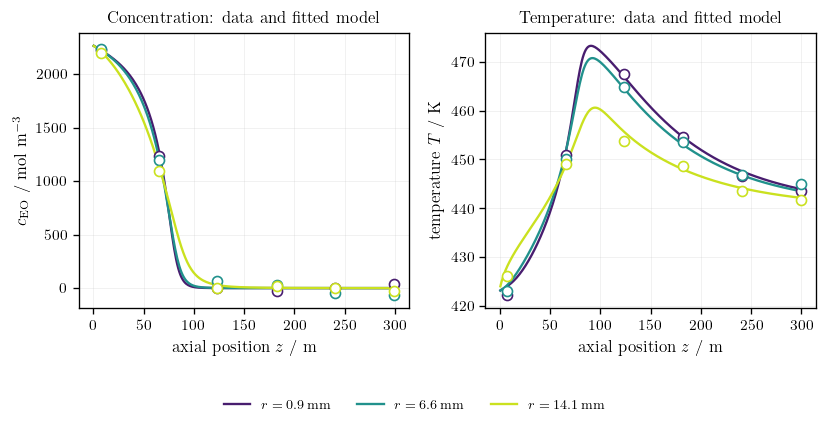

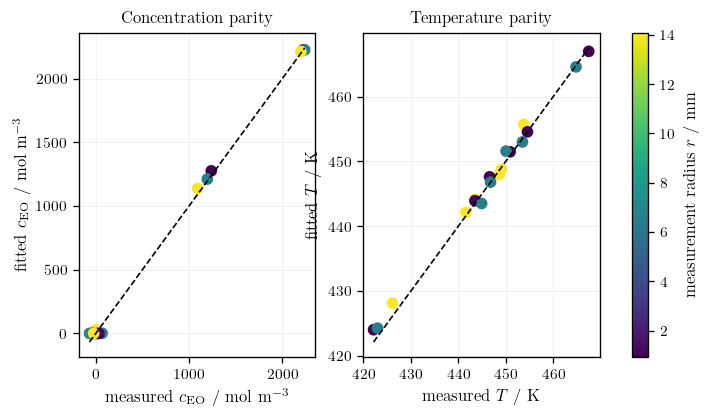

RMSE against noisy measurements: 33.12 mol m^-3 and 1.070 K


In [61]:
fit_solution = simulate_2d(p, h_wall=h_fitted, k0=k0_fitted, t_eval=[p.t_end])
c_fitted, T_fitted = unpack_solution(fit_solution, p)
c_prediction = c_fitted[measurement_index]
T_prediction = T_fitted[measurement_index]

fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.6))
for j, (ir, color) in enumerate(zip(ir_measure, measurement_colors)):
    radial_label = fr"$r={1000*p.r[ir]:.1f}\,\mathrm{{mm}}$"
    axes[0].plot(p.z, c_fitted[:, ir], color=color, label=radial_label)
    axes[0].scatter(z_measure, c_measured[:, j], facecolors="white", edgecolors=color, zorder=3)
    axes[1].plot(p.z, T_fitted[:, ir], color=color)
    axes[1].scatter(z_measure, T_measured[:, j], facecolors="white", edgecolors=color, zorder=3)
axes[0].set_xlabel(r"axial position $z$ / m")
axes[0].set_ylabel(r"$c_{\mathrm{EO}}$ / mol m$^{-3}$")
axes[0].set_title("Concentration: data and fitted model")
axes[1].set_xlabel(r"axial position $z$ / m")
axes[1].set_ylabel(r"temperature $T$ / K")
axes[1].set_title("Temperature: data and fitted model")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.005), ncol=3, frameon=False)
fig.tight_layout(rect=(0.0, 0.12, 1.0, 1.0))
save_publication_figure(fig, "ex6_fit_profiles")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.5))
points = axes[0].scatter(c_measured, c_prediction, c=1000*p.r[ir_measure][None, :].repeat(len(iz_measure), axis=0))
lo, hi = min(c_measured.min(), c_prediction.min()), max(c_measured.max(), c_prediction.max())
axes[0].plot([lo, hi], [lo, hi], "k--", lw=1)
axes[0].set_xlabel(r"measured $c_{\mathrm{EO}}$ / mol m$^{-3}$")
axes[0].set_ylabel(r"fitted $c_{\mathrm{EO}}$ / mol m$^{-3}$")
axes[0].set_title("Concentration parity")
axes[1].scatter(T_measured, T_prediction, c=1000*p.r[ir_measure][None, :].repeat(len(iz_measure), axis=0))
lo, hi = min(T_measured.min(), T_prediction.min()), max(T_measured.max(), T_prediction.max())
axes[1].plot([lo, hi], [lo, hi], "k--", lw=1)
axes[1].set_xlabel(r"measured $T$ / K")
axes[1].set_ylabel(r"fitted $T$ / K")
axes[1].set_title("Temperature parity")
fig.colorbar(points, ax=axes, label=r"measurement radius $r$ / mm")
save_publication_figure(fig, "ex6_parameter_fit")
plt.show()

rmse_c = np.sqrt(np.mean((c_prediction - c_measured)**2))
rmse_T = np.sqrt(np.mean((T_prediction - T_measured)**2))
print(f"RMSE against noisy measurements: {rmse_c:.2f} mol m^-3 and {rmse_T:.3f} K")


## Discussion

1. The hotspot is located on the centerline because heat must travel radially to the cooled wall. A one-dimensional cross-section-averaged model cannot display this center-to-wall difference.
2. Radial temperature differences also create radial kinetic-rate and concentration differences even though the inlet is radially uniform.
3. Annular finite volumes enforce symmetry naturally: the center face has zero area, while the wall heat flux is included only in the outer annulus.
4. Synthetic measurements recover both $h_w$ and $k_0$ close to their known values. Temperature primarily constrains heat release and removal, while concentration helps distinguish kinetics from heat transfer.
5. The fitted quantities are effective model parameters. With real data, grid convergence, sensor positions, uncertainty, parameter correlation, and structural model error should be examined before physical interpretation.
